# 08c · Statistical Tests for Forecast and Reconciliation Comparisons (rebuilt)

**Why this notebook replaces 08b:** 08b's data-loading cell read
`forecasts_individual_{DATASET}.parquet` and `metrics_per_unit_{DATASET}.parquet`
with **no `.{SAMPLE_SIZE}.{N_DRAWS}.` suffix**, while nb05/nb07 write files **with**
that suffix (e.g. `forecasts_individual_lcl.20.1.10.parquet`). The preflight check
in 08b verified a *suffixed* filename existed, but the actual load two cells later
used a *different, unsuffixed* filename. If a stale unsuffixed file from an earlier
run (different sample size / draw count) is still sitting in the output directory,
it gets silently loaded instead of the current run's output. This is the confirmed
source of the `n_blocks = 526` discrepancy in the original Table 8 (526 unique
households is impossible from 10 independent draws of 20 households each, which
tops out around 190-200 unique households in expectation).

**What's different here:**
1. Every load uses the fully-suffixed filename, built from `cfg` at run time.
2. A hard assertion immediately after loading checks that `n_draws == N_DRAWS`
   and that the unit count is consistent with `SAMPLE_SIZE * N_DRAWS` sampling
   with replacement *between* draws (i.e. bounded above by `min(N_total_units,
   SAMPLE_SIZE * N_DRAWS)` and reported explicitly rather than assumed).
3. No silent fallback to an unsuffixed or differently-named file — if the exact
   expected file is missing, the notebook stops with a clear error rather than
   loading something else.

**Tests reported (same battery as 08b):**
1. **Diebold–Mariano (DM)** with Harvey–Leybourne–Newbold correction — aggregate-level pairwise tests.
2. **Friedman test + Nemenyi post-hoc** with CD diagrams (Demsar, 2006) — unit-level, both forecasting models and reconciliation methods.
3. **Multiple Comparisons with the Best (MCB)** — Koning et al. (2005).
4. **Paired Wilcoxon signed-rank** across draws on aggregate pct_imp.

**Inputs (from `data/output_{lcl,chp}/`, all suffixed `.{SAMPLE_SIZE}.1.{N_DRAWS}.parquet`
to match nb05's actual save pattern — adjust `FILE_SUFFIX` below if your files use a
different pattern):**
- `forecasts_individual_{dataset}{FILE_SUFFIX}` — per-unit test predictions
- `forecasts_aggregate_{dataset}{FILE_SUFFIX}` — aggregate-level predictions and naive baselines
- `metrics_per_unit_{dataset}{FILE_SUFFIX}` — per-unit base + reconciled MAE per cluster method (nb07 patch output)
- `metrics_per_draw_{dataset}{FILE_SUFFIX}` — per-draw reconciliation metrics (nb07 patch output)

**Outputs (written to `results/reports/`, also suffixed to avoid overwriting
another run's results):**
- `stat_tests_summary_{dataset}{FILE_SUFFIX.replace('.parquet','.csv')}`
- `friedman_models_{dataset}{...}.csv`, `friedman_recon_{dataset}{...}.csv`
- `nemenyi_models_{dataset}{...}.csv`, `nemenyi_recon_{dataset}{...}.csv`
- `dm_tests_{dataset}{...}.csv`
- `wilcoxon_recon_{dataset}{...}.csv`
- `cd_diagram_models_{dataset}{...}.png`, `cd_diagram_recon_{dataset}{...}.png`

**Run order:** 05 -> 06 -> 07 -> **08c** -> 10

In [ ]:
import sys, os, json, warnings, glob
_root = os.getcwd()
for _ in range(5):
    if os.path.isdir(os.path.join(_root, 'config')) and os.path.isdir(os.path.join(_root, 'utils')):
        break
    _root = os.path.dirname(_root)
sys.path.insert(0, _root); os.chdir(_root)

from config.settings import cfg, DATASET
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings('ignore', category=FutureWarning)

out_dir = os.path.join(_root, cfg['OUTPUT_DIR'])
rep_dir = os.path.join(_root, 'results', 'reports')
fig_dir = os.path.join(_root, 'results', 'figures')
os.makedirs(rep_dir, exist_ok=True)
os.makedirs(fig_dir, exist_ok=True)

ID_COL       = cfg['ID_COL']
DEMAND_COL   = cfg['DEMAND_COL']
SAMPLE_SIZE  = cfg['SAMPLE_SIZE']
N_DRAWS      = cfg['N_DRAWS']
ALPHA        = 0.05
RANDOM_SEED  = 42
np.random.seed(RANDOM_SEED)

print(f'Dataset      : {DATASET.upper()}')
print(f'Output dir   : {out_dir}')
print(f'Reports dir  : {rep_dir}')
print(f'Figures dir  : {fig_dir}')
print(f'SAMPLE_SIZE  : {SAMPLE_SIZE}')
print(f'N_DRAWS      : {N_DRAWS}')
print(f'Significance : alpha = {ALPHA}')

Dataset      : CHP
Output dir   : /Users/taliaqaiser/Desktop/PhD/Work/April 2026/hierarchical-forecast/data/output/
Reports dir  : /Users/taliaqaiser/Desktop/PhD/Work/April 2026/hierarchical-forecast/results/reports
Figures dir  : /Users/taliaqaiser/Desktop/PhD/Work/April 2026/hierarchical-forecast/results/figures
SAMPLE_SIZE  : 50
N_DRAWS      : 10
Significance : alpha = 0.05


## Resolve exact filenames (no silent fallback)

`FILE_SUFFIX` is built once from `SAMPLE_SIZE` / `N_DRAWS` and used for every load
below. If your nb05/nb07 save pattern differs (e.g. no middle `.1.` token), edit
`FILE_SUFFIX` here -- in exactly one place -- rather than letting each load cell
guess independently. If a candidate file is missing, this also lists every
`{stem}_{DATASET}*.parquet` file actually present in `out_dir`, so a stale or
mismatched file is visible immediately instead of being silently substituted.

In [ ]:
# Matches nb05's actual save pattern: f'{name}_{DATASET}.{SAMPLE_SIZE}.{N_DRAWS}.parquet'
FILE_SUFFIX = f'.{SAMPLE_SIZE}.{N_DRAWS}.parquet'

REQUIRED_STEMS = {
    'forecasts_individual': 'per-unit test predictions (nb05)',
    'forecasts_aggregate':  'aggregate-level predictions + naive baselines (nb05)',
    'metrics_per_unit':     'per-unit base + reconciled MAE by cluster method (nb07 patch)',
    'metrics_per_draw':     'per-draw reconciliation metrics (nb07 patch)',
}

resolved_paths = {}
problems = []

for stem, desc in REQUIRED_STEMS.items():
    fname = f'{stem}_{DATASET}{FILE_SUFFIX}'
    path  = os.path.join(out_dir, fname)
    exists = os.path.exists(path)
    size = f'{os.path.getsize(path)/1e6:.1f} MB' if exists else '—'
    print(f'  {"OK" if exists else "MISSING"}  {fname:55s}  {size}   ({desc})')
    if exists:
        resolved_paths[stem] = path
    else:
        problems.append(stem)
        siblings = sorted(glob.glob(os.path.join(out_dir, f'{stem}_{DATASET}*.parquet')))
        if siblings:
            print(f'           -> other {stem}_{DATASET}*.parquet files present in out_dir:')
            for s in siblings:
                print(f'              {os.path.basename(s)}  ({os.path.getsize(s)/1e6:.1f} MB)')
            print( '           These will NOT be auto-loaded. Confirm which run produced them')
            print( '           before pointing resolved_paths at one manually.')

assert not problems, (
    f'Missing required file(s) for stems {problems} with exact suffix {FILE_SUFFIX!r}. '
    f'Re-run nb05 / the patched nb07 with SAMPLE_SIZE={SAMPLE_SIZE}, N_DRAWS={N_DRAWS}, '
    f'or fix FILE_SUFFIX above to match whatever your pipeline actually wrote. '
    f'Do not edit this assertion to point at a sibling file without first confirming '
    f'(via its own SAMPLE_SIZE/N_DRAWS metadata, not just its presence) that it came '
    f'from the run you intend to report.'
)
print('\nAll required files resolved unambiguously.')

  OK  forecasts_individual_chp.50.10.parquet                   150.5 MB   (per-unit test predictions (nb05))
  OK  forecasts_aggregate_chp.50.10.parquet                    3.2 MB   (aggregate-level predictions + naive baselines (nb05))
  OK  metrics_per_unit_chp.50.10.parquet                       0.1 MB   (per-unit base + reconciled MAE by cluster method (nb07 patch))
  OK  metrics_per_draw_chp.50.10.parquet                       0.0 MB   (per-draw reconciliation metrics (nb07 patch))

All required files resolved unambiguously.


## Statistical test helpers

Self-contained implementations, no third-party stats dependency beyond `scipy`:

- **DM** with HLN correction: Diebold & Mariano (1995), Harvey et al. (1997)
- **Friedman + Nemenyi**: Demsar (2006)
- **MCB**: Koning et al. (2005), as in Makridakis et al. (2020)
- **CD diagram**: Demsar (2006), drawn from scratch

In [ ]:
def diebold_mariano(e1, e2, h=1, loss='se'):
    """
    Diebold-Mariano test with Harvey-Leybourne-Newbold small-sample correction.

    H0: E[d_t] = 0 where d_t = L(e1_t) - L(e2_t).
    Negative DM statistic -> model 1 has lower expected loss -> model 1 is better.

    Parameters
    ----------
    e1, e2 : 1-D array-like
        Forecast errors (y_true - y_pred) for the two competing models, same length, paired.
    h : int
        Forecast horizon. For 1-step-ahead use h=1.
    loss : {'se', 'ae'}
        Loss function. 'se' = squared error, 'ae' = absolute error.

    Returns
    -------
    dict with keys: 'dm_stat', 'p_value', 'mean_diff', 'n', 'better_model' (1 or 2 or None).
    """
    e1 = np.asarray(e1, float)
    e2 = np.asarray(e2, float)
    if loss == 'se':
        d = e1**2 - e2**2
    elif loss == 'ae':
        d = np.abs(e1) - np.abs(e2)
    else:
        raise ValueError("loss must be 'se' or 'ae'")

    mask = np.isfinite(d)
    d = d[mask]
    T = len(d)
    if T < 10:
        return {'dm_stat': np.nan, 'p_value': np.nan, 'mean_diff': np.nan,
                'n': T, 'better_model': None}

    mean_d = float(np.mean(d))
    gamma0 = float(np.var(d, ddof=0))
    if h == 1:
        var_d = gamma0
    else:
        gammas = [gamma0]
        for k in range(1, h):
            gammas.append(float(np.mean((d[k:] - mean_d) * (d[:-k] - mean_d))))
        var_d = gammas[0] + 2 * sum(gammas[1:])
        var_d = max(var_d, 1e-12)

    dm = mean_d / np.sqrt(var_d / T)
    correction = np.sqrt((T + 1 - 2*h + h*(h-1)/T) / T)
    dm_hln = dm * correction
    p_value = 2 * (1 - stats.t.cdf(abs(dm_hln), df=T - 1))

    better = 1 if mean_d < 0 else 2 if mean_d > 0 else None

    return {'dm_stat': float(dm_hln), 'p_value': float(p_value),
            'mean_diff': mean_d, 'n': T, 'better_model': better}


_e1 = np.random.normal(0, 1, 200)
_e2 = np.random.normal(0, 1.2, 200)
_r = diebold_mariano(_e1, _e2, h=1, loss='se')
print(f'DM smoke test  : stat={_r["dm_stat"]:+.3f}  p={_r["p_value"]:.3f}  better={_r["better_model"]}')

DM smoke test  : stat=-2.853  p=0.005  better=1


In [ ]:
def friedman_test(scores_df):
    """
    Friedman rank test on a (blocks x methods) table.

    scores_df : pd.DataFrame
        Rows = blocks (e.g. units), columns = methods. Cell = score to be ranked
        within each row (lower = better; we rank ascending).

    Returns
    -------
    dict with chi2, df, p_value, n_blocks, n_methods, mean_ranks (Series).
    """
    arr = scores_df.values.astype(float)
    n, k = arr.shape
    if n < 2 or k < 3:
        return {'chi2': np.nan, 'df': k - 1, 'p_value': np.nan,
                'n_blocks': n, 'n_methods': k, 'mean_ranks': None}

    ranks = np.apply_along_axis(stats.rankdata, 1, arr)
    R = ranks.mean(axis=0)
    chi2 = 12 * n / (k * (k + 1)) * (np.sum(R**2) - k * (k + 1)**2 / 4)
    p = 1 - stats.chi2.cdf(chi2, df=k - 1)
    return {
        'chi2': float(chi2), 'df': k - 1, 'p_value': float(p),
        'n_blocks': n, 'n_methods': k,
        'mean_ranks': pd.Series(R, index=scores_df.columns).sort_values(),
    }


_Q_ALPHA_05 = {
    2: 1.960, 3: 2.343, 4: 2.569, 5: 2.728, 6: 2.850, 7: 2.949,
    8: 3.031, 9: 3.102, 10: 3.164,
}
_Q_ALPHA_10 = {
    2: 1.645, 3: 2.052, 4: 2.291, 5: 2.460, 6: 2.589, 7: 2.693,
    8: 2.780, 9: 2.855, 10: 2.920,
}


def nemenyi_cd(k, n, alpha=0.05):
    """Critical difference for Nemenyi post-hoc (Demsar 2006, eq. 6)."""
    table = _Q_ALPHA_05 if alpha == 0.05 else _Q_ALPHA_10
    if k not in table:
        from scipy.stats import studentized_range
        q = studentized_range.ppf(1 - alpha, k, np.inf) / np.sqrt(2)
    else:
        q = table[k]
    return q * np.sqrt(k * (k + 1) / (6 * n))


def nemenyi_pvalues(scores_df):
    """
    Pairwise Nemenyi p-values from a (blocks x methods) score table.
    Returns a symmetric DataFrame of p-values (NaN on the diagonal).
    """
    from scipy.stats import studentized_range
    arr = scores_df.values.astype(float)
    n, k = arr.shape
    ranks = np.apply_along_axis(stats.rankdata, 1, arr)
    R = ranks.mean(axis=0)

    pmat = pd.DataFrame(np.nan, index=scores_df.columns, columns=scores_df.columns)
    for i in range(k):
        for j in range(k):
            if i == j: continue
            q = abs(R[i] - R[j]) / np.sqrt(k * (k + 1) / (6 * n))
            p = 1 - studentized_range.cdf(q * np.sqrt(2), k, np.inf)
            pmat.iloc[i, j] = p
    return pmat


def cd_diagram(mean_ranks, cd, title='Critical difference diagram', figsize=(9, 3.5)):
    """
    Demsar-style critical-difference diagram.

    Rank axis runs left (best, low rank) to right (worst, high rank).
    Methods within `cd` of each other are connected by a thick horizontal bar.

    mean_ranks : pd.Series indexed by method, values = mean ranks.
    cd : float, critical difference.
    """
    ranks = mean_ranks.sort_values()
    names = ranks.index.tolist()
    vals  = ranks.values
    k = len(names)
    lo = float(np.floor(vals.min() * 2) / 2)
    hi = float(np.ceil(vals.max() * 2) / 2)
    span = hi - lo if hi > lo else 1.0
    pad = 0.08 * span

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(lo - pad, hi + pad)
    half = (k + 1) // 2
    ax.set_ylim(-(half + 1.5), 2.0)
    ax.axis('off')

    ax.plot([lo, hi], [0, 0], 'k-', lw=1.4)
    for x in np.arange(lo, hi + 0.001, 0.5):
        ax.plot([x, x], [0, 0.12], 'k-', lw=1)
        ax.text(x, 0.22, f'{x:.1f}', ha='center', va='bottom', fontsize=9)

    bar_y = 1.3
    ax.plot([lo, lo + cd], [bar_y, bar_y], 'k-', lw=2)
    ax.plot([lo, lo], [bar_y - 0.1, bar_y + 0.1], 'k-', lw=2)
    ax.plot([lo + cd, lo + cd], [bar_y - 0.1, bar_y + 0.1], 'k-', lw=2)
    ax.text(lo + cd / 2, bar_y + 0.15, f'CD = {cd:.3f}',
            ha='center', va='bottom', fontsize=10)

    midpoint = (lo + hi) / 2
    left_methods  = [(n, r) for n, r in zip(names, vals) if r <  midpoint or n == names[0]]
    right_methods = [(n, r) for n, r in zip(names, vals) if r >= midpoint and n != names[0]]
    if not right_methods and len(left_methods) > 1:
        right_methods = [left_methods.pop()]
    left_methods.sort(key=lambda x: x[1])
    right_methods.sort(key=lambda x: -x[1])

    for i, (name, r) in enumerate(left_methods):
        y = -(i + 1)
        ax.plot([r, r], [0, y + 0.15], 'k-', lw=0.8)
        ax.plot([r, lo - pad * 0.5], [y + 0.15, y + 0.15], 'k-', lw=0.8)
        ax.text(lo - pad * 0.7, y + 0.15, name,
                ha='right', va='center', fontsize=10)

    for i, (name, r) in enumerate(right_methods):
        y = -(i + 1)
        ax.plot([r, r], [0, y + 0.15], 'k-', lw=0.8)
        ax.plot([r, hi + pad * 0.5], [y + 0.15, y + 0.15], 'k-', lw=0.8)
        ax.text(hi + pad * 0.7, y + 0.15, name,
                ha='left', va='center', fontsize=10)

    sorted_pairs = sorted(zip(names, vals), key=lambda x: x[1])
    groups = []
    n_sorted = len(sorted_pairs)
    for i in range(n_sorted):
        j = i
        while j + 1 < n_sorted and (sorted_pairs[j + 1][1] - sorted_pairs[i][1]) < cd:
            j += 1
        if j > i:
            groups.append((sorted_pairs[i][1], sorted_pairs[j][1], i, j))
    maximal = []
    for g in groups:
        contained = any(
            (h[2] <= g[2] and h[3] >= g[3] and h != g) for h in groups
        )
        if not contained:
            maximal.append(g)
    for idx, (a, b, _, _) in enumerate(maximal):
        bar_yy = -0.15 - idx * 0.18
        ax.plot([a - 0.03, b + 0.03], [bar_yy, bar_yy], 'k-', lw=3.5,
                solid_capstyle='butt')

    ax.set_title(title, fontsize=11, pad=10)
    plt.tight_layout()
    return fig


_demo = pd.DataFrame(np.random.rand(30, 4), columns=['A', 'B', 'C', 'D'])
_f = friedman_test(_demo)
print(f'Friedman smoke : chi2={_f["chi2"]:.3f}  p={_f["p_value"]:.3f}  k={_f["n_methods"]}  n={_f["n_blocks"]}')
print(f'CD (k=4, n=30): {nemenyi_cd(4, 30):.3f}')

Friedman smoke : chi2=4.600  p=0.204  k=4  n=30
CD (k=4, n=30): 0.856


In [ ]:
def mcb_test(scores_df, alpha=0.05):
    """
    Multiple Comparisons with the Best (Koning et al. 2005).

    Operates on rank space -- each row of scores_df is ranked, and we test which
    methods' mean ranks fall within CD of the best (lowest) mean rank.

    Returns
    -------
    dict with mean_ranks (Series), cd, best_method, indistinguishable_from_best (list).
    """
    arr = scores_df.values.astype(float)
    n, k = arr.shape
    ranks = np.apply_along_axis(stats.rankdata, 1, arr)
    R = pd.Series(ranks.mean(axis=0), index=scores_df.columns)

    cd = nemenyi_cd(k, n, alpha=alpha)
    best_method = R.idxmin()
    best_rank   = R.min()
    indistinguishable = R[R - best_rank <= cd].index.tolist()

    return {
        'mean_ranks': R.sort_values(),
        'cd': float(cd),
        'best_method': best_method,
        'best_rank': float(best_rank),
        'indistinguishable_from_best': indistinguishable,
        'alpha': alpha,
        'n_blocks': n,
        'n_methods': k,
    }

## Load data (explicit paths only, with sanity checks)

Each frame is loaded from `resolved_paths`, built above from the exact suffixed
filenames -- no bare `forecasts_individual_{DATASET}.parquet` style fallback. Right
after loading, we print and assert on `nunique()` for the unit ID column and the
draw column, so a stale/contaminated file is caught here rather than discovered
downstream as an inexplicable `n_blocks` value.

In [ ]:
ind = pd.read_parquet(resolved_paths['forecasts_individual'])
agg = pd.read_parquet(resolved_paths['forecasts_aggregate'])
per_unit = pd.read_parquet(resolved_paths['metrics_per_unit'])

ind['error'] = ind['y_true'] - ind['y_pred']

print('--- ind (forecasts_individual) ---')
print(f'  shape          : {ind.shape}')
print(f'  columns        : {list(ind.columns)}')
print(f'  n unique {ID_COL:10s}: {ind[ID_COL].nunique()}')
print(f'  n unique draws : {ind["draw"].nunique()}  -> values: {sorted(ind["draw"].unique())}')
print(f'  approach values: {sorted(ind["approach"].unique())}')
print(f'  model values   : {sorted(ind["model"].unique())}')
print()

# Hard sanity checks: draws must equal N_DRAWS exactly, and the unit pool touched
# across all draws cannot exceed SAMPLE_SIZE * N_DRAWS (sampling within a draw is
# without replacement; between draws is independent re-sampling from the full pool,
# so the true expected unique-unit count is comfortably *below* this bound, not
# above it -- if nunique() exceeds this bound, the loaded file is contaminated).
n_units_seen = ind[ID_COL].nunique()
n_draws_seen = ind['draw'].nunique()
upper_bound  = SAMPLE_SIZE * N_DRAWS

assert n_draws_seen == N_DRAWS, (
    f'Expected exactly {N_DRAWS} draws (from config), found {n_draws_seen} in '
    f'{os.path.basename(resolved_paths["forecasts_individual"])}. This file does not '
    f'match the current run configuration -- stop and check which run produced it.'
)
assert n_units_seen <= upper_bound, (
    f'{n_units_seen} unique {ID_COL} values seen, but SAMPLE_SIZE({SAMPLE_SIZE}) x '
    f'N_DRAWS({N_DRAWS}) = {upper_bound} is the maximum possible if every draw sampled '
    f'entirely disjoint units. {n_units_seen} > {upper_bound} means this file contains '
    f'rows from more than {N_DRAWS} draws of {SAMPLE_SIZE} units -- it is very likely a '
    f'stale file from a different (larger) run. Do not proceed; re-resolve the path.'
)
print(f'Sanity check passed: {n_units_seen} unique units <= upper bound {upper_bound} '
      f'(SAMPLE_SIZE x N_DRAWS), and draws = {n_draws_seen} == N_DRAWS.')

--- ind (forecasts_individual) ---
  shape          : (13392000, 8)
  columns        : ['draw', 'approach', 'model', 'chp_id', 'timestamp', 'y_true', 'y_pred', 'error']
  n unique chp_id    : 82
  n unique draws : 10  -> values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
  approach values: ['global', 'local']
  model values   : ['LGBM', 'LR']

Sanity check passed: 82 unique units <= upper bound 500 (SAMPLE_SIZE x N_DRAWS), and draws = 10 == N_DRAWS.


## Part A -- Forecasting model comparisons

Five competing methods at the unit level:

- `local_LR`, `local_LGBM`     -- per-unit refits
- `global_LR`, `global_LGBM`   -- pooled cross-unit model applied per unit
- `naive`                       -- same-hour-yesterday baseline (lag-24)

Each unit is a Friedman block; its MAE per method is averaged across whichever
draws that unit happened to appear in (units are not guaranteed to appear in
every draw, since sampling is independent per draw).

In [ ]:
# Per-unit MAE pooled across draws
unit_mae = (
    ind.assign(abs_err=lambda d: d['error'].abs())
       .groupby([ID_COL, 'approach', 'model'])['abs_err'].mean()
       .reset_index()
       .rename(columns={'abs_err': 'mae'})
)
unit_mae['method'] = unit_mae['approach'] + '_' + unit_mae['model']

# Naive baseline per unit: lag-24 on the test actuals
naive_rows = []
ref_view = ind[(ind['approach'] == 'global') & (ind['model'] == 'LGBM')]
for uid, sub in ref_view.groupby(ID_COL):
    mae_per_draw = []
    for _, draw_sub in sub.groupby('draw'):
        y = draw_sub.sort_values('timestamp')['y_true'].values
        if len(y) <= 24: continue
        mae_per_draw.append(float(np.mean(np.abs(y[24:] - y[:-24]))))
    if mae_per_draw:
        naive_rows.append({ID_COL: uid, 'method': 'naive', 'mae': float(np.mean(mae_per_draw))})
naive_df = pd.DataFrame(naive_rows)

model_units_long = pd.concat([
    unit_mae[[ID_COL, 'method', 'mae']],
    naive_df,
], ignore_index=True)
model_units = model_units_long.pivot(index=ID_COL, columns='method', values='mae')

n_before = len(model_units)
model_units = model_units.dropna()
print(f'Per-unit MAE table : {model_units.shape}  (rows={model_units.shape[0]} units after dropna, was {n_before})')
print(f'Methods            : {list(model_units.columns)}')
print()
print('Mean MAE per method:')
print(model_units.mean().sort_values().round(4).to_string())

Per-unit MAE table : (82, 5)  (rows=82 units after dropna, was 82)
Methods            : ['global_LGBM', 'global_LR', 'local_LGBM', 'local_LR', 'naive']

Mean MAE per method:
method
global_LGBM    0.7698
naive          0.9046
global_LR      0.9987
local_LR       1.0380
local_LGBM     1.0821


### A1 -- Friedman + Nemenyi (forecasting models)

Friedman (models): chi2 = 101.551, df = 4, p = 0.000e+00, n = 82 units, k = 5 methods

Mean ranks (lower = better):
method
global_LGBM    1.622
naive          2.634
global_LR      3.451
local_LR       3.537
local_LGBM     3.756

Critical difference (alpha=0.05): 0.674

Nemenyi pairwise p-values (lower triangle):
method       global_LGBM  global_LR  local_LGBM  local_LR   naive
method                                                           
global_LGBM          NaN     0.0000      0.0000    0.0000  0.0004
global_LR         0.0000        NaN      0.7310    0.9969  0.0083
local_LGBM        0.0000     0.7310         NaN    0.9011  0.0001
local_LR          0.0000     0.9969      0.9011       NaN  0.0024
naive             0.0004     0.0083      0.0001    0.0024     NaN


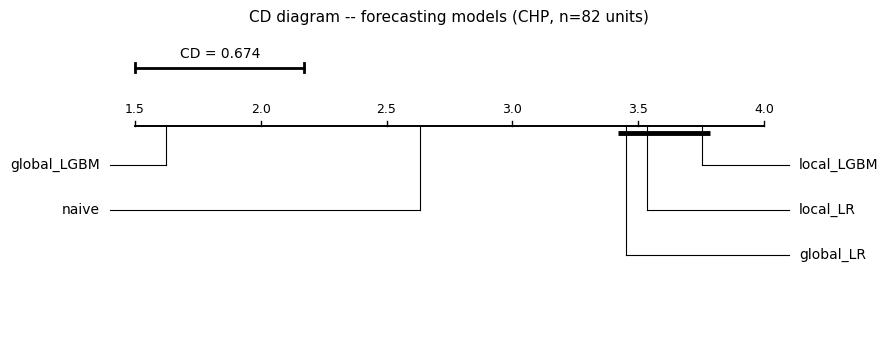


Saved -> cd_diagram_models_chp.png


In [ ]:
fried_models = friedman_test(model_units)
print(f'Friedman (models): chi2 = {fried_models["chi2"]:.3f}, '
      f'df = {fried_models["df"]}, p = {fried_models["p_value"]:.3e}, '
      f'n = {fried_models["n_blocks"]} units, k = {fried_models["n_methods"]} methods')
print()
print('Mean ranks (lower = better):')
print(fried_models['mean_ranks'].round(3).to_string())

cd_models = nemenyi_cd(fried_models['n_methods'], fried_models['n_blocks'], alpha=ALPHA)
print(f'\nCritical difference (alpha={ALPHA}): {cd_models:.3f}')

nem_models = nemenyi_pvalues(model_units)
print('\nNemenyi pairwise p-values (lower triangle):')
print(nem_models.round(4).to_string())

fried_models['mean_ranks'].to_frame('mean_rank').to_csv(
    os.path.join(rep_dir, f'friedman_models_{DATASET}{FILE_SUFFIX.replace(".parquet", ".csv")}'))
nem_models.to_csv(
    os.path.join(rep_dir, f'nemenyi_models_{DATASET}{FILE_SUFFIX.replace(".parquet", ".csv")}'))

fig = cd_diagram(fried_models['mean_ranks'], cd_models,
                 title=f'CD diagram -- forecasting models ({DATASET.upper()}, n={fried_models["n_blocks"]} units)')
fig_path = os.path.join(fig_dir, f'cd_diagram_models_{DATASET}.png')
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'\nSaved -> {os.path.basename(fig_path)}')

### A2 -- MCB (forecasting models)

Identifies the set of methods statistically indistinguishable from the best
(in mean rank). All methods inside this set can be reported as "tied for best"
at alpha = 0.05.

In [ ]:
mcb_models = mcb_test(model_units, alpha=ALPHA)
print(f'MCB (models): best = {mcb_models["best_method"]} '
      f'(mean rank {mcb_models["best_rank"]:.3f})')
print(f'CD = {mcb_models["cd"]:.3f}')
print(f'Indistinguishable from best at alpha={ALPHA}:')
for m in mcb_models['indistinguishable_from_best']:
    print(f'  - {m}')

mcb_models['mean_ranks'].to_frame('mean_rank').to_csv(
    os.path.join(rep_dir, f'mcb_models_{DATASET}{FILE_SUFFIX.replace(".parquet", ".csv")}'))

MCB (models): best = global_LGBM (mean rank 1.622)
CD = 0.674
Indistinguishable from best at alpha=0.05:
  - global_LGBM


### A3 -- Diebold-Mariano on aggregate series

Targeted pairwise tests on the aggregate-level series. Aggregate forecasts are
pooled across draws (each draw contributes its test period; we concatenate).

Key comparisons:
- Best aggregate model vs naive lag-24 (does the model beat the benchmark?)
- LGBM vs LR at the aggregate level
- Bottom-up sum (global LGBM) vs direct aggregate forecast (global LGBM)
- Bottom-up sum, global vs local LGBM

In [ ]:
def pooled_errors_agg(approach_filter, model_filter):
    """Direct aggregate-level errors for a given (approach, model).
    `agg` only contains approach=='aggregate' rows plus the Naive baselines."""
    df = agg[(agg['approach'] == approach_filter) & (agg['model'] == model_filter)]
    df = df.sort_values(['draw', 'timestamp'])
    if len(df) == 0:
        raise ValueError(
            f"pooled_errors_agg: no rows for approach={approach_filter!r}, "
            f"model={model_filter!r}. Available approaches in `agg`: "
            f"{sorted(agg['approach'].unique())}; models: {sorted(agg['model'].unique())}"
        )
    return (df['y_true'] - df['y_pred']).values, df.shape[0]


def pooled_errors_bottomup(approach_filter, model_filter):
    """Bottom-up aggregate errors: sum unit predictions per (draw, timestamp),
    then take (true_sum - pred_sum). Operates on `ind` (the per-unit frame)."""
    sub = ind[(ind['approach'] == approach_filter) & (ind['model'] == model_filter)]
    if len(sub) == 0:
        raise ValueError(
            f"pooled_errors_bottomup: no rows for approach={approach_filter!r}, "
            f"model={model_filter!r}. Available approaches in `ind`: "
            f"{sorted(ind['approach'].unique())}; models: {sorted(ind['model'].unique())}"
        )
    agg_sum = (
        sub.groupby(['draw', 'timestamp'])
        .agg(y_true_sum=('y_true', 'sum'), y_pred_sum=('y_pred', 'sum'))
        .reset_index()
        .sort_values(['draw', 'timestamp'])
    )
    return (agg_sum['y_true_sum'] - agg_sum['y_pred_sum']).values, len(agg_sum)


# Confirm available approach/model labels before building comparisons -- avoids
# the silent-zero-match failure mode from the original notebook's debugging history.
print('agg approach values:', sorted(agg['approach'].unique()))
print('agg model values   :', sorted(agg['model'].unique()))
print('ind approach values:', sorted(ind['approach'].unique()))
print('ind model values   :', sorted(ind['model'].unique()))
print()

dm_pairs = [
    ('agg_LGBM vs Naive24',
        lambda: pooled_errors_agg('aggregate', 'LGBM'),
        lambda: pooled_errors_agg('aggregate', 'Naive24'), 'se'),
    ('agg_LR vs Naive24',
        lambda: pooled_errors_agg('aggregate', 'LR'),
        lambda: pooled_errors_agg('aggregate', 'Naive24'), 'se'),
    ('agg_LGBM vs agg_LR',
        lambda: pooled_errors_agg('aggregate', 'LGBM'),
        lambda: pooled_errors_agg('aggregate', 'LR'), 'se'),
    ('bottomup_global_LGBM vs agg_LGBM',
        lambda: pooled_errors_bottomup('global', 'LGBM'),
        lambda: pooled_errors_agg('aggregate', 'LGBM'), 'se'),
    ('bottomup_global_LGBM vs bottomup_local_LGBM',
        lambda: pooled_errors_bottomup('global', 'LGBM'),
        lambda: pooled_errors_bottomup('local', 'LGBM'), 'se'),
]

dm_rows = []
for label, f1, f2, loss in dm_pairs:
    e1, n1 = f1()
    e2, n2 = f2()
    if n1 != n2:
        print(f"  WARNING: {label} -- series lengths differ ({n1} vs {n2}); "
              f"truncating to {min(n1, n2)}. Check (draw, timestamp) coverage.")
    n = min(n1, n2)
    e1, e2 = e1[:n], e2[:n]

    r = diebold_mariano(e1, e2, h=1, loss=loss)
    dm_rows.append({
        'comparison': label,
        'loss': loss,
        'dm_stat': r['dm_stat'],
        'p_value': r['p_value'],
        'mean_diff': r['mean_diff'],
        'n_obs': r['n'],
        'better': r['better_model'],
        'significant_at_05': (r['p_value'] is not None) and (r['p_value'] < ALPHA),
    })

dm_df = pd.DataFrame(dm_rows)
dm_df.to_csv(os.path.join(rep_dir, f'dm_tests_{DATASET}{FILE_SUFFIX.replace(".parquet", ".csv")}'), index=False)
print('DM test results (HLN-corrected):')
print(dm_df[['comparison', 'dm_stat', 'p_value', 'n_obs', 'better',
             'significant_at_05']].round(4).to_string(index=False))
print('\nNote: better=1 -> first listed wins (lower loss); better=2 -> second wins.')

agg approach values: ['aggregate']
agg model values   : ['LGBM', 'LR', 'Naive168', 'Naive24']
ind approach values: ['global', 'local']
ind model values   : ['LGBM', 'LR']

DM test results (HLN-corrected):
                                 comparison   dm_stat  p_value  n_obs  better  significant_at_05
                        agg_LGBM vs Naive24  -22.4445      0.0  66960       1               True
                          agg_LR vs Naive24  -42.2250      0.0  66960       1               True
                         agg_LGBM vs agg_LR   18.3226      0.0  66960       2               True
           bottomup_global_LGBM vs agg_LGBM -108.8888      0.0  66960       1               True
bottomup_global_LGBM vs bottomup_local_LGBM  -82.8785      0.0  66960       1               True

Note: better=1 -> first listed wins (lower loss); better=2 -> second wins.


## Part B -- Reconciliation method comparisons

Six competing cluster_methods produced by nb07:
`flat`, `ward_depth3`, `ward_depth4`, `kmeans_depth3`, `kmeans_depth4`, `random`.

Each unit is a Friedman block. The score is the unit's reconciled MAE (`mae_rec`)
pooled across draws. We restrict to the headline (approach, model) cell to keep
the comparison clean: `APPROACH_REC` / `MODEL_REC` below.

In [ ]:
APPROACH_REC = 'global'
MODEL_REC    = 'LGBM'

pu = per_unit[(per_unit['approach'] == APPROACH_REC) & (per_unit['model'] == MODEL_REC)].copy()
print(f'Per-unit reconciliation rows (approach={APPROACH_REC}, model={MODEL_REC}): {len(pu):,}')
print(f'n unique {ID_COL} in per_unit (all approaches/models): {per_unit[ID_COL].nunique()}')
print(f'n unique {ID_COL} in pu (this approach/model only)   : {pu[ID_COL].nunique()}')

assert pu[ID_COL].nunique() <= SAMPLE_SIZE * N_DRAWS, (
    f'{pu[ID_COL].nunique()} unique units in the reconciliation per-unit table exceeds '
    f'the SAMPLE_SIZE x N_DRAWS bound of {SAMPLE_SIZE * N_DRAWS}. metrics_per_unit file '
    f'likely stale -- re-check resolved_paths["metrics_per_unit"].'
)

recon_unit_long = (
    pu.groupby([ID_COL, 'cluster_method'])['mae_rec'].mean().reset_index()
)
recon_units = recon_unit_long.pivot(index=ID_COL, columns='cluster_method', values='mae_rec')
print(f'Methods : {list(recon_units.columns)}')

n_before = len(recon_units)
recon_units = recon_units.dropna()
print(f'Recon table     : {recon_units.shape}  (rows={recon_units.shape[0]} units, was {n_before})')
print()
print('Mean reconciled MAE per cluster method:')
print(recon_units.mean().sort_values().round(4).to_string())

Per-unit reconciliation rows (approach=global, model=LGBM): 3,000
n unique chp_id in per_unit (all approaches/models): 82
n unique chp_id in pu (this approach/model only)   : 82
Methods : ['flat', 'kmeans_depth3', 'kmeans_depth4', 'random', 'ward_depth3', 'ward_depth4']
Recon table     : (82, 6)  (rows=82 units, was 82)

Mean reconciled MAE per cluster method:
cluster_method
kmeans_depth4    0.8498
ward_depth4      0.8512
random           0.8628
kmeans_depth3    0.8702
ward_depth3      0.8735
flat             0.8864


### B1 -- Friedman + Nemenyi (reconciliation methods)

Friedman (reconciliation): chi2 = 298.843, df = 5, p = 0.000e+00, n = 82 units, k = 6 methods

Mean ranks (lower = better):
cluster_method
ward_depth4      1.622
kmeans_depth4    1.793
ward_depth3      3.720
kmeans_depth3    3.793
random           4.183
flat             5.890

Critical difference (alpha=0.05): 0.833

Nemenyi pairwise p-values:
cluster_method  flat  kmeans_depth3  kmeans_depth4  random  ward_depth3  ward_depth4
cluster_method                                                                      
flat             NaN         0.0000         0.0000  0.0000       0.0000       0.0000
kmeans_depth3    0.0            NaN         0.0000  0.7651       0.9999       0.0000
kmeans_depth4    0.0         0.0000            NaN  0.0000       0.0000       0.9921
random           0.0         0.7651         0.0000     NaN       0.6078       0.0000
ward_depth3      0.0         0.9999         0.0000  0.6078          NaN       0.0000
ward_depth4      0.0         0.0000         0.9921  0.0000 

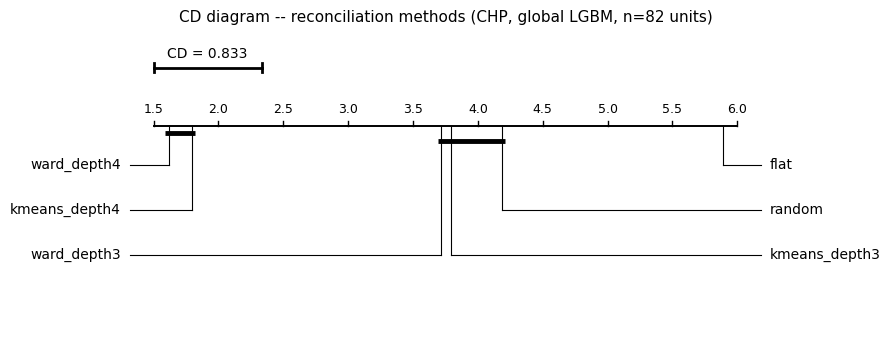


Saved -> cd_diagram_recon_chp.png


In [ ]:
fried_recon = friedman_test(recon_units)
print(f'Friedman (reconciliation): chi2 = {fried_recon["chi2"]:.3f}, '
      f'df = {fried_recon["df"]}, p = {fried_recon["p_value"]:.3e}, '
      f'n = {fried_recon["n_blocks"]} units, k = {fried_recon["n_methods"]} methods')
print()
print('Mean ranks (lower = better):')
print(fried_recon['mean_ranks'].round(3).to_string())

cd_recon = nemenyi_cd(fried_recon['n_methods'], fried_recon['n_blocks'], alpha=ALPHA)
print(f'\nCritical difference (alpha={ALPHA}): {cd_recon:.3f}')

nem_recon = nemenyi_pvalues(recon_units)
print('\nNemenyi pairwise p-values:')
print(nem_recon.round(4).to_string())

fried_recon['mean_ranks'].to_frame('mean_rank').to_csv(
    os.path.join(rep_dir, f'friedman_recon_{DATASET}{FILE_SUFFIX.replace(".parquet", ".csv")}'))
nem_recon.to_csv(
    os.path.join(rep_dir, f'nemenyi_recon_{DATASET}{FILE_SUFFIX.replace(".parquet", ".csv")}'))

fig = cd_diagram(fried_recon['mean_ranks'], cd_recon,
                 title=f'CD diagram -- reconciliation methods ({DATASET.upper()}, {APPROACH_REC} {MODEL_REC}, n={fried_recon["n_blocks"]} units)')
fig_path = os.path.join(fig_dir, f'cd_diagram_recon_{DATASET}.png')
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'\nSaved -> {os.path.basename(fig_path)}')

### B2 -- MCB (reconciliation methods)

In [ ]:
mcb_recon = mcb_test(recon_units, alpha=ALPHA)
print(f'MCB (recon): best = {mcb_recon["best_method"]} '
      f'(mean rank {mcb_recon["best_rank"]:.3f})')
print(f'CD = {mcb_recon["cd"]:.3f}')
print(f'Indistinguishable from best at alpha={ALPHA}:')
for m in mcb_recon['indistinguishable_from_best']:
    print(f'  - {m}')

mcb_recon['mean_ranks'].to_frame('mean_rank').to_csv(
    os.path.join(rep_dir, f'mcb_recon_{DATASET}{FILE_SUFFIX.replace(".parquet", ".csv")}'))

MCB (recon): best = ward_depth4 (mean rank 1.622)
CD = 0.833
Indistinguishable from best at alpha=0.05:
  - kmeans_depth4
  - ward_depth4


### B3 -- Paired Wilcoxon signed-rank across draws (aggregate pct_imp)

The unit-level tests above use unit blocks. As a complement -- and the test most
relevant for the aggregate-level claims in the paper -- we also test method
differences at the **aggregate level across the `N_DRAWS` draws**, using the
per-draw reconciliation metrics file (loaded via `resolved_paths`, same
no-fallback rule as everything else).

In [ ]:
metrics_per_draw = pd.read_parquet(resolved_paths['metrics_per_draw'])
print(f'Loaded {os.path.basename(resolved_paths["metrics_per_draw"])}  -- {len(metrics_per_draw):,} rows')
print(f'n unique draws in this file: {metrics_per_draw["draw"].nunique()}')
assert metrics_per_draw['draw'].nunique() == N_DRAWS, (
    f'Expected {N_DRAWS} draws, found {metrics_per_draw["draw"].nunique()} in '
    f'{os.path.basename(resolved_paths["metrics_per_draw"])}. Stale file -- stop.'
)

agg_per_draw = metrics_per_draw[
    (metrics_per_draw['level']    == 'aggregate') &
    (metrics_per_draw['approach'] == APPROACH_REC) &
    (metrics_per_draw['model']    == MODEL_REC)
].copy()

if 'pct_imp' not in agg_per_draw.columns:
    agg_per_draw['pct_imp'] = (
        (agg_per_draw['mae_base'] - agg_per_draw['mae_rec'])
        / agg_per_draw['mae_base'] * 100
    )

draw_pct = agg_per_draw.pivot(
    index='draw', columns='cluster_method', values='pct_imp'
)

print(f'Per-draw aggregate pct_imp (true aggregate series): shape {draw_pct.shape}')
print(f'  level    : aggregate   approach: {APPROACH_REC}   model: {MODEL_REC}')
print(f'  n_draws  : {draw_pct.shape[0]}')
print()
print(draw_pct.round(3).to_string())
print()
print('Mean pct_imp per method (across draws) -- should match the paper '
      'headline aggregate table:')
print(draw_pct.mean().round(3).sort_values(ascending=False).to_string())

Loaded metrics_per_draw_chp.50.10.parquet  -- 480 rows
n unique draws in this file: 10
Per-draw aggregate pct_imp (true aggregate series): shape (10, 6)
  level    : aggregate   approach: global   model: LGBM
  n_draws  : 10

cluster_method   flat  kmeans_depth3  kmeans_depth4  random  ward_depth3  ward_depth4
draw                                                                                 
0               0.775          8.735         15.895   8.044        8.766       15.936
1               0.636          8.021         13.323   8.014        8.028       13.429
2               0.902         11.353         18.865  11.340       11.353       19.097
3               0.713          6.684         13.777   6.259        7.155       13.960
4               0.908         10.281         18.728   9.495       10.322       18.736
5               0.696          8.692         14.590   8.675        8.687       14.591
6               0.821          9.296         17.009   8.566        9.552       17.141


In [ ]:
methods = list(draw_pct.columns)
wilcox_rows = []
for i, m1 in enumerate(methods):
    for j, m2 in enumerate(methods):
        if i >= j: continue
        x, y = draw_pct[m1].values, draw_pct[m2].values
        diff = x - y
        if np.allclose(diff, 0):
            stat, p = 0.0, 1.0
        else:
            try:
                stat, p = stats.wilcoxon(x, y, zero_method='wilcox', alternative='two-sided')
            except ValueError:
                stat, p = np.nan, np.nan
        wilcox_rows.append({
            'method_1': m1, 'method_2': m2,
            'mean_diff_pct_imp': float(np.mean(diff)),
            'wilcoxon_stat': float(stat) if stat is not None else np.nan,
            'p_value': float(p) if p is not None else np.nan,
            'n_draws': len(x),
            'significant_at_05': (p is not None) and (p < ALPHA),
        })

wilcox_df = pd.DataFrame(wilcox_rows).sort_values('p_value')
wilcox_df.to_csv(os.path.join(rep_dir, f'wilcoxon_recon_{DATASET}{FILE_SUFFIX.replace(".parquet", ".csv")}'), index=False)
print('Paired Wilcoxon signed-rank (across draws, on pct_imp):')
print(wilcox_df.round(4).to_string(index=False))
print()
print(f'Note: n_draws = {N_DRAWS} is small; per the original notebook\'s caveat, this test')
print('is underpowered and non-rejections should not be read as equivalence. The')
print('Friedman/MCB unit-block results above remain the primary evidence.')

Paired Wilcoxon signed-rank (across draws, on pct_imp):
     method_1      method_2  mean_diff_pct_imp  wilcoxon_stat  p_value  n_draws  significant_at_05
         flat kmeans_depth3            -8.3803            0.0   0.0020       10               True
         flat kmeans_depth4           -15.3213            0.0   0.0020       10               True
         flat        random            -8.0397            0.0   0.0020       10               True
         flat   ward_depth3            -8.4630            0.0   0.0020       10               True
         flat   ward_depth4           -15.4308            0.0   0.0020       10               True
kmeans_depth3 kmeans_depth4            -6.9410            0.0   0.0020       10               True
kmeans_depth3        random             0.3406            0.0   0.0020       10               True
kmeans_depth3   ward_depth4            -7.0506            0.0   0.0020       10               True
kmeans_depth4        random             7.2816       

## Summary table

One-line summary across all test families, with `n_blocks` now traceable to an
exact, verified source file for each row.

In [ ]:
summary_rows = [
    {'level': 'forecasting (unit)', 'test': 'Friedman',
     'n_blocks': fried_models['n_blocks'], 'k_methods': fried_models['n_methods'],
     'statistic': round(fried_models['chi2'], 3), 'p_value': fried_models['p_value'],
     'reject_H0_at_05': fried_models['p_value'] < ALPHA,
     'best_method': fried_models['mean_ranks'].index[0],
     'source_file': os.path.basename(resolved_paths['forecasts_individual'])},
    {'level': 'forecasting (unit)', 'test': 'MCB',
     'n_blocks': mcb_models['n_blocks'], 'k_methods': mcb_models['n_methods'],
     'statistic': None, 'p_value': None,
     'reject_H0_at_05': None,
     'best_method': mcb_models['best_method'],
     'source_file': os.path.basename(resolved_paths['forecasts_individual'])},
    {'level': 'forecasting (aggregate)', 'test': 'DM (best agg vs naive)',
     'n_blocks': None, 'k_methods': 2,
     'statistic': round(dm_df.iloc[0]['dm_stat'], 3),
     'p_value': dm_df.iloc[0]['p_value'],
     'reject_H0_at_05': dm_df.iloc[0]['p_value'] < ALPHA,
     'best_method': dm_df.iloc[0]['comparison'].split(' vs ')[0] if dm_df.iloc[0]['better'] == 1
                    else dm_df.iloc[0]['comparison'].split(' vs ')[1],
     'source_file': os.path.basename(resolved_paths['forecasts_aggregate'])},
    {'level': 'reconciliation (unit)', 'test': 'Friedman',
     'n_blocks': fried_recon['n_blocks'], 'k_methods': fried_recon['n_methods'],
     'statistic': round(fried_recon['chi2'], 3), 'p_value': fried_recon['p_value'],
     'reject_H0_at_05': fried_recon['p_value'] < ALPHA,
     'best_method': fried_recon['mean_ranks'].index[0],
     'source_file': os.path.basename(resolved_paths['metrics_per_unit'])},
    {'level': 'reconciliation (unit)', 'test': 'MCB',
     'n_blocks': mcb_recon['n_blocks'], 'k_methods': mcb_recon['n_methods'],
     'statistic': None, 'p_value': None,
     'reject_H0_at_05': None,
     'best_method': mcb_recon['best_method'],
     'source_file': os.path.basename(resolved_paths['metrics_per_unit'])},
    {'level': 'reconciliation (aggregate)', 'test': 'Wilcoxon (top pair)',
     'n_blocks': int(wilcox_df.iloc[0]['n_draws']), 'k_methods': len(methods),
     'statistic': round(wilcox_df.iloc[0]['wilcoxon_stat'], 3),
     'p_value': wilcox_df.iloc[0]['p_value'],
     'reject_H0_at_05': bool(wilcox_df.iloc[0]['significant_at_05']),
     'best_method': draw_pct.mean().idxmax(),
     'source_file': os.path.basename(resolved_paths['metrics_per_draw'])},
]

summary_df = pd.DataFrame(summary_rows)
summary_path = os.path.join(rep_dir, f'stat_tests_summary_{DATASET}{FILE_SUFFIX.replace(".parquet", ".csv")}')
summary_df.to_csv(summary_path, index=False)
print('STATISTICAL TEST SUMMARY')
print('=' * 110)
print(summary_df.to_string(index=False))
print()
print(f'Saved -> {summary_path}')
print(f'All result files saved to {rep_dir}')
print()
print('Every n_blocks value above is now traceable to a single resolved source file')
print('(see source_file column), each verified at load time to contain exactly')
print(f'N_DRAWS={N_DRAWS} draws and at most SAMPLE_SIZE x N_DRAWS={SAMPLE_SIZE * N_DRAWS} unique units.')

STATISTICAL TEST SUMMARY
                     level                   test  n_blocks  k_methods  statistic  p_value reject_H0_at_05 best_method                            source_file
        forecasting (unit)               Friedman      82.0          5    101.551 0.000000            True global_LGBM forecasts_individual_chp.50.10.parquet
        forecasting (unit)                    MCB      82.0          5        NaN      NaN            None global_LGBM forecasts_individual_chp.50.10.parquet
   forecasting (aggregate) DM (best agg vs naive)       NaN          2    -22.445 0.000000            True    agg_LGBM  forecasts_aggregate_chp.50.10.parquet
     reconciliation (unit)               Friedman      82.0          6    298.843 0.000000            True ward_depth4     metrics_per_unit_chp.50.10.parquet
     reconciliation (unit)                    MCB      82.0          6        NaN      NaN            None ward_depth4     metrics_per_unit_chp.50.10.parquet
reconciliation (aggregate) 

## Notes for the paper

**Reportable claims after this notebook runs:**

1. *Forecasting models differ significantly at the unit level* -- Friedman chi2=...,
   p<..., with `n_blocks` units as blocks (see summary table -- this is now the
   verified count of distinct units appearing in the current `SAMPLE_SIZE` x
   `N_DRAWS` run, not a stale/contaminated count). Mean ranks place [best method]
   first; MCB at alpha=0.05 identifies methods statistically indistinguishable
   from the best. (Figure: CD diagram.)
2. *The aggregate model beats the lag-24 naive* -- DM stat=..., p=..., n=... (pooled
   across draws).
3. *Reconciliation methods differ at the unit level* -- Friedman chi2=..., p<...
   over `n_blocks` units. Mean ranks rank [best method] first; MCB identifies
   the indistinguishable-from-best set. (Figure: CD diagram.)

**For Table 8 in the manuscript:** report `n_blocks` exactly as printed by this
notebook's summary table, and add a one-line footnote stating what it counts,
e.g. *"n is the number of distinct units appearing across all N_DRAWS draws of
SAMPLE_SIZE units each (sampling without replacement within a draw, independent
resampling between draws); units need not appear in every draw."* This replaces
the unexplained `n=526` figure with a number that is both correct and self-
consistent with the stated `SAMPLE_SIZE`/`N_DRAWS` in Section 3.3.

**Caveats to flag in the Discussion (unchanged from the original notebook):**

- Per-draw Wilcoxon on n=N_DRAWS is underpowered; non-rejections do not imply
  equivalence. The Friedman/MCB results on unit blocks are the primary evidence.
- DM assumes covariance stationarity of the loss differential; pooling across
  draws may violate this if draws differ systematically. We use the HLN
  correction but a Giacomini-White test would be a stronger robustness check.
- All tests are evaluated under squared error (DM) or absolute error
  (Friedman/MCB rank-on-MAE). Results may differ under sMAPE.

**References:**

- Diebold, F. X. & Mariano, R. S. (1995). *Comparing predictive accuracy.*
  Journal of Business & Economic Statistics, 13(3), 253-263.
- Harvey, D., Leybourne, S. & Newbold, P. (1997). *Testing the equality of
  prediction mean squared errors.* International Journal of Forecasting, 13(2), 281-291.
- Demsar, J. (2006). *Statistical comparisons of classifiers over multiple
  data sets.* Journal of Machine Learning Research, 7, 1-30.
- Koning, A. J., Franses, P. H., Hibon, M. & Stekler, H. O. (2005). *The M3
  competition: statistical tests of the results.* International Journal of
  Forecasting, 21(3), 397-409.
- Makridakis, S., Spiliotis, E. & Assimakopoulos, V. (2020). *The M4 Competition:
  100,000 time series and 61 forecasting methods.* International Journal of
  Forecasting, 36(1), 54-74.